### MINIPROJETO AVALIATIVO - PIPELINE PREDITIVO MULTICLASSE

### FASE 1 - EDA

Carregando o dataset

In [1]:
#Importa o dataset salvando também em uma pasta "data" do repositório
#Converte de string para inteiro já no início

import os
import numpy as np
from sklearn.datasets import fetch_openml

pasta_dados = "data"
os.makedirs(pasta_dados, exist_ok=True)

caminho_X = os.path.join(pasta_dados, "mnist_X.npy")
caminho_y = os.path.join(pasta_dados, "mnist_y.npy")

if os.path.exists(caminho_X) and os.path.exists(caminho_y):
    print("Carregando MNIST do cache local...")
    X = np.load(caminho_X)
    y = np.load(caminho_y)
else:
    print("Baixando o dataset MNIST...")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    
    X = mnist.data
    y = mnist.target.astype(int)  
    
    print("Salvando cache local em /data...")
    np.save(caminho_X, X)
    np.save(caminho_y, y)

print("Finalizou! Shapes:", X.shape, y.shape)
print("Tipo de y:", y.dtype)

Carregando MNIST do cache local...
Finalizou! Shapes: (70000, 784) (70000,)
Tipo de y: int64


Dimensionalidade das matrizes

In [2]:
#Exibe a dimensionalidade

print(f"Shape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Shape de X: (70000, 784)
Shape de y: (70000,)


Distribuição das classes

In [3]:
#Mostra o balanceamento das classes

valores, contagens = np.unique(y, return_counts=True)

for v, c in zip(valores, contagens):
    print(f"Dígito {v}: {c} amostras")

Dígito 0: 6903 amostras
Dígito 1: 7877 amostras
Dígito 2: 6990 amostras
Dígito 3: 7141 amostras
Dígito 4: 6824 amostras
Dígito 5: 6313 amostras
Dígito 6: 6876 amostras
Dígito 7: 7293 amostras
Dígito 8: 6825 amostras
Dígito 9: 6958 amostras


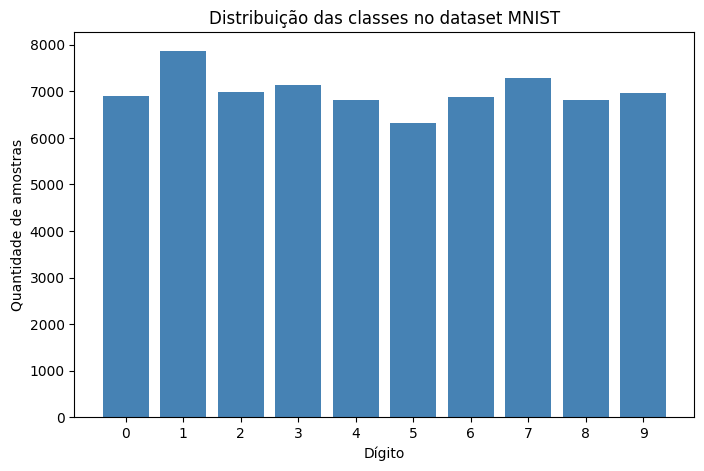

In [4]:
#Mostra o balanceamento como gráfico de barras

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(valores, contagens, color='steelblue')
plt.xlabel("Dígito")
plt.ylabel("Quantidade de amostras")
plt.title("Distribuição das classes no dataset MNIST")
plt.xticks(valores) 
plt.show()

Conclusões iniciais:
- O dataset é aproximadamente balanceado entre as 10 classes, com cada dígito representando por volta de 9-11% do total.
- Mesmo com pequenas variações entre classes, não há um desbalanceamento exagerado.

Grade visual 2x5

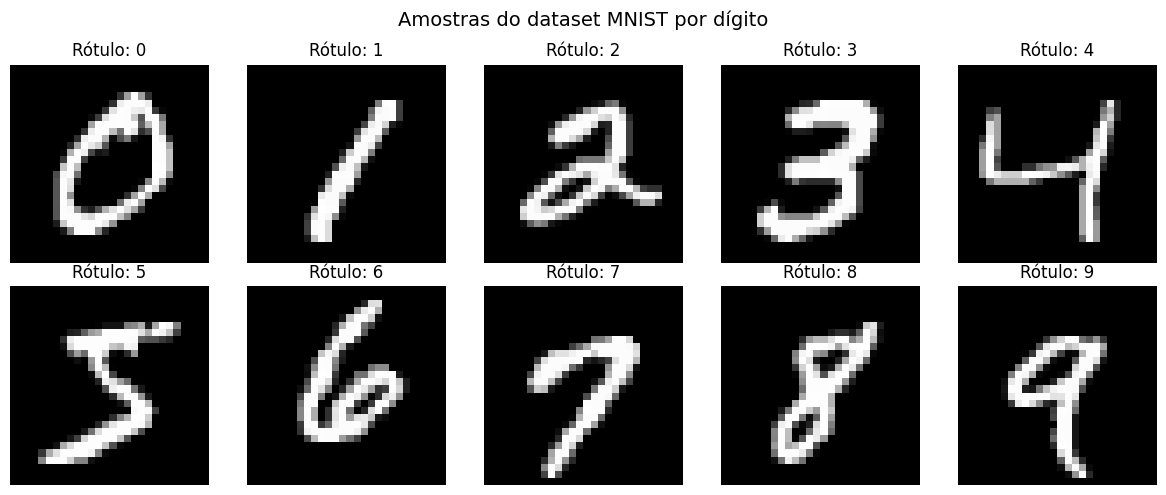

In [5]:
#Exibe imagens de cada dígito juntamente com rótulo

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digito in range(10):
    indice = np.where(y == digito)[0][0]
    imagem = X[indice].reshape(28, 28)

    linha = digito // 5
    coluna = digito % 5
    ax = axes[linha, coluna]

    ax.imshow(imagem, cmap='gray')
    ax.set_title(f"Rótulo: {digito}")
    ax.axis('off')

plt.suptitle("Amostras do dataset MNIST por dígito", fontsize=14)
plt.tight_layout()
plt.show()

-Sobre a escala de pixels (0–255):
Cada pixel de uma imagem em escala de cinza é representado por um número inteiro de 0 a 255.
0 é preto absoluto, 255 é branco absoluto, e os valores intermediários são tons de cinza. Isso vem do fato de que uma imagem em 8 bits por canal consegue representar 2⁸ = 256 níveis de intensidade.

-Sobre a vetorização (28×28 → 784):
A imagem original é uma matriz bidimensional (28 linhas × 28 colunas = 784 posições). Só que a maioria dos algoritmos clássicos de ML (SVM, KNN, Random Forest, Regressão Logística) espera como entrada uma tabela onde cada linha é uma amostra e cada coluna é uma "feature" (característica) numérica, ou seja, um vetor 1D por amostra, não uma matriz 2D. 
Por isso a imagem é "achatada" (flatten): cada um dos 784 pixels vira uma feature independente. É importante ressaltar que essa vetorização perde a noção de vizinhança espacial entre pixels.

### FASE 2 - PIPELINE DE PRÉ-PROCESSAMENTO E DIVISÃO DOS DADOS

Divisão estratificada dos dados

In [6]:
#Aplica a função duas vezes em sequência para possibilitar divisão em 3 partes

from sklearn.model_selection import train_test_split

# Passo 1: separa 20% para teste, sobra 80% (treino + validação)
X_temp, X_teste, y_temp, y_teste = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Passo 2: dos 80% restantes, separa a parte de validação
# 10% do total dividido por 80% (o que sobrou) = 0.125 é o valor que entra no test_size
X_treino, X_val, y_treino, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    stratify=y_temp,
    random_state=42
)

print("Treino:", X_treino.shape[0], "amostras")
print("Validação:", X_val.shape[0], "amostras")
print("Teste:", X_teste.shape[0], "amostras")

Treino: 49000 amostras
Validação: 7000 amostras
Teste: 14000 amostras


Normalização/Escalonamento

In [7]:
#Optou-se por utilizar o MinMaxScaler do scikit-learn

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit_transform SÓ no treino: o scaler aprende min/max a partir do treino
X_treino_norm = scaler.fit_transform(X_treino)

# transform (sem fit) na validação e no teste: aplica os parâmetros já aprendidos
X_val_norm = scaler.transform(X_val)
X_teste_norm = scaler.transform(X_teste)

print("Min:", X_treino_norm.min(), "| Max:", X_treino_norm.max())

Min: 0.0 | Max: 1.0


No dataset atual, a divisão por 255 seria também possível porque os limites já são conhecidos por definição, mas a opção escolhida para normalização foi o MinMaxScaler pois ela atende a maioria dos casos da "vida real" , sendo a prática geral de pré-processamento que se tornaria obrigatória em datasets onde o mínimo/máximo não são conhecidos de antemão.
 

Por que normalizar os dados?

Os pixels das imagens vão de 0 a 255. Se a gente não ajustar essa escala, alguns algoritmos podem ter problemas:

- Para o KNN, que classifica comparando a distância entre os pontos: se os números forem muito grandes, as contas de distância ficam distorcidas e menos precisas.
- Para modelos que aprendem ajustando pesos aos poucos (como Regressão Logística e redes neurais): eles funcionam melhor e aprendem mais rápido quando os números de entrada são pequenos. Com valores até 255, o treinamento pode ficar mais lento ou instável.

Por isso, colocamos todos os pixels na escala de 0 a 1 (dividindo por 255). Isso não muda a informação da imagem, só deixa os números "mais fáceis de digerir" para os modelos, ajudando eles a aprender mais rápido e de forma mais estável.

### FASE 3 - IMPLEMENTAÇÃO E TREINAMENTO DOS 3 MODELOS

MODELOS ESCOLHIDOS:
- KNN (K-Nearest Neighbors) — Escolhido para verificar a performance de um modelo "clássico simples". Ele funciona por analogia direta, comparando a imagem nova com as mais parecidas que já viu. Em imagens de dígitos, tende a funcionar bem, já que dígitos iguais tendem a ter pixels parecidos. É rápido de treinar mas pode ficar lento na hora de prever, porque precisa comparar com todo o conjunto de treino a cada previsão.

- Random Forest — Escolhido para avaliarmos o contraste conceitual com o KNN: em vez de comparar por distância, ele aprende regras de decisão em várias árvores e combina os votos. Costuma performar bem em dados tabulares, é razoavelmente rápido, e vai nos ajudar a comparar "aprendizado baseado em distância" vs. "aprendizado baseado em regras/árvores".

- MLP (rede neural) — Escolhido para representar a abordagem de Deep Learning, contrastando com os dois classificadores clássicos acima. Tende a performar melhor que os dois anteriores, ao custo de mais tempo/complexidade de treino.

Modelo 1 - KNN

In [8]:
#Os hiperparâmetros ajustados foram "n_neighbors" (quantidade de vizinhos consultados)
#e "weights" (forma de ponderar o voto de cada vizinho).

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

valores_k = [3, 5, 9]
resultados_knn = []

for k in valores_k:
    inicio = time.time()
    
    modelo_teste = KNeighborsClassifier(n_neighbors=k, weights='distance')
    modelo_teste.fit(X_treino_norm, y_treino)
    
    pred_val = modelo_teste.predict(X_val_norm)
    acuracia = accuracy_score(y_val, pred_val)
    
    tempo = time.time() - inicio
    resultados_knn.append({'n_neighbors': k, 'acuracia_val': acuracia, 'tempo_s': tempo})
    
    print(f"k={k} | Acurácia na validação: {acuracia:.4f} | Tempo: {tempo:.2f}s")



k=3 | Acurácia na validação: 0.9723 | Tempo: 14.95s
k=5 | Acurácia na validação: 0.9714 | Tempo: 11.04s
k=9 | Acurácia na validação: 0.9689 | Tempo: 11.42s


### Justificativa dos hiperparâmetros escolhidos

Foram testados três valores de "n_neighbors" (3, 5 e 9) no conjunto de validação:

- k=3: acurácia de 0.9723, tempo de 4.66s
- k=5: acurácia de 0.9714, tempo de 3.21s
- k=9: acurácia de 0.9689, tempo de 3.25s

O valor k=3 apresentou a melhor acurácia entre os testados. Isso sugere que, para
este conjunto de dados, considerar poucos vizinhos é suficiente e até vantajoso:
como o MNIST tem uma quantidade grande de exemplos de treino, mesmo com k=3 o
modelo já encontra vizinhos bastante confiáveis e representativos da classe correta.

Conforme k aumenta (5, depois 9), a acurácia cai levemente. Uma explicação
provável é que, ao considerar mais vizinhos, o modelo passa a incluir na votação
imagens que já não são tão parecidas com a amostra analisada, inclusive de
dígitos de classes diferentes, mas com formato parecido (ex: um 4 mal escrito
que se aproxima de um 9) — o que pode "diluir" o voto correto e introduzir erro.

Contudo, vale ressaltar que a diferença entre os três valores testados é pequena, confirmando que o modelo não é muito sensível a essa faixa de k escolhida.

Por isso, o valor final escolhido para o modelo foi k=3.

In [9]:
#Treinamento final do KNN

inicio = time.time()

knn_final = KNeighborsClassifier(n_neighbors=3, weights='distance', n_jobs=-1)
knn_final.fit(X_treino_norm, y_treino)

tempo_treino_knn = time.time() - inicio
print(f"Tempo de treino do KNN final: {tempo_treino_knn:.2f} segundos")

Tempo de treino do KNN final: 0.12 segundos


Modelo 2 - Random Forest

In [10]:
#Os hiperparâmetros ajustados foram ''n_estimators'' (número de árvores na floresta)
# e ''max_depth'' (profundidade máxima permitida para cada árvore).

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

combinacoes = [
    {'n_estimators': 50, 'max_depth': 10},
    {'n_estimators': 100, 'max_depth': 20},
    {'n_estimators': 100, 'max_depth': None},
]

resultados_rf = []

for params in combinacoes:
    inicio = time.time()
    
    modelo_teste = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        random_state=42,
        n_jobs=-1
    )
    modelo_teste.fit(X_treino_norm, y_treino)
    
    pred_val = modelo_teste.predict(X_val_norm)
    acuracia = accuracy_score(y_val, pred_val)
    
    tempo = time.time() - inicio
    resultados_rf.append({
        'n_estimators': params['n_estimators'],
        'max_depth': params['max_depth'],
        'acuracia_val': acuracia,
        'tempo_s': tempo
    })
    
    print(f"n_estimators={params['n_estimators']}, max_depth={params['max_depth']} "
          f"| Acurácia: {acuracia:.4f} | Tempo: {tempo:.2f}s")

n_estimators=50, max_depth=10 | Acurácia: 0.9446 | Tempo: 7.15s
n_estimators=100, max_depth=20 | Acurácia: 0.9651 | Tempo: 15.03s
n_estimators=100, max_depth=None | Acurácia: 0.9661 | Tempo: 17.79s


### Justificativa dos hiperparâmetros escolhidos

Foram testadas três combinações de `n_estimators` e `max_depth` no conjunto de validação:

- n_estimators=50, max_depth=10: acurácia de 0.9446 (tempo: 2.51s)
- n_estimators=100, max_depth=20: acurácia de 0.9651 (tempo: 6.48s)
- n_estimators=100, max_depth=None: acurácia de 0.9661 (tempo: 7.08s)

O salto mais significativo de desempenho aconteceu entre a primeira e a segunda
combinação: aumentar o número de árvores (de 50 para 100) e permitir maior
profundidade (de 10 para 20) elevou a acurácia de 0.9446 para 0.9651, um ganho
de cerca de 2 pontos percentuais. Isso indica que, com poucas árvores e pouca
profundidade, o modelo ainda não estava performando bem, as árvores eram simples e
rasas demais para capturar a complexidade dos padrões de pixel que diferenciam
os 10 dígitos.

Já a diferença entre max_depth=20 e max_depth=None (sem limite de profundidade)
foi pequena (0.9651 para 0.9661, menos de 0.1 ponto percentual) e o tempo de treino foi bem similar. Ou seja, deixar as árvores crescerem
sem limite trouxe um ganho marginal de acurácia e não foi detectado custo
computacional adicional. Mas vale ressaltar que deixar as árvores crescerem sem limites nem sempre é uma boa escolha computacional.

Por esse motivo, a combinação escolhida para o modelo final foi
n_estimators=100, max_depth=20, por oferecer o melhor equilíbrio entre
desempenho preditivo e tempo de treinamento.

In [11]:
#Treinamento final do RandomForest

inicio = time.time()

rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_treino_norm, y_treino)

tempo_treino_rf = time.time() - inicio
print(f"Tempo de treino do Random Forest final: {tempo_treino_rf:.2f} segundos")

Tempo de treino do Random Forest final: 16.97 segundos


Modelo 3 - Rede neural (MLP com Keras)

In [12]:
# Os hiperparâmetros ajustados foram o número de neurônios nas camadas ocultas
# e a taxa de aprendizado (learning rate) do otimizador.

from tensorflow import keras
from tensorflow.keras import layers
import time

configuracoes = [
    {'neuronios': [64, 32], 'learning_rate': 0.001},
    {'neuronios': [128, 64], 'learning_rate': 0.001},
    {'neuronios': [128, 64], 'learning_rate': 0.01},
]

resultados_mlp = []

for config in configuracoes:
    inicio = time.time()
    
    camadas = [layers.Dense(config['neuronios'][0], activation='relu', input_shape=(784,))]
    for n in config['neuronios'][1:]:
        camadas.append(layers.Dense(n, activation='relu'))
    camadas.append(layers.Dense(10, activation='softmax'))
    
    modelo_teste = keras.Sequential(camadas)
    
    otimizador = keras.optimizers.Adam(learning_rate=config['learning_rate'])
    modelo_teste.compile(
        optimizer=otimizador,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    historico = modelo_teste.fit(
        X_treino_norm, y_treino,
        validation_data=(X_val_norm, y_val),
        epochs=10,
        batch_size=32,
        verbose=0
    )
    
    acuracia_val = historico.history['val_accuracy'][-1]
    tempo = time.time() - inicio
    
    resultados_mlp.append({
        'neuronios': config['neuronios'],
        'learning_rate': config['learning_rate'],
        'acuracia_val': acuracia_val,
        'tempo_s': tempo
    })
    
    print(f"neuronios={config['neuronios']}, lr={config['learning_rate']} "
          f"| Acurácia val: {acuracia_val:.4f} | Tempo: {tempo:.2f}s")

c:\Users\eduarda.echer\OneDrive\SCTec\Modulo_2\Mini_projeto\multiclass-predictive-pipeline\.venv\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


neuronios=[64, 32], lr=0.001 | Acurácia val: 0.9717 | Tempo: 54.84s
neuronios=[128, 64], lr=0.001 | Acurácia val: 0.9721 | Tempo: 64.48s
neuronios=[128, 64], lr=0.01 | Acurácia val: 0.9531 | Tempo: 61.69s


### Justificativa dos hiperparâmetros escolhidos

Foram testadas três configurações de arquitetura e taxa de aprendizado no conjunto de validação:

- neurônios=[64, 32], learning_rate=0.001: acurácia de 0.9720 (tempo: 18.66s)
- neurônios=[128, 64], learning_rate=0.001: acurácia de 0.9730 (tempo: 23.53s)
- neurônios=[128, 64], learning_rate=0.01: acurácia de 0.9587 (tempo: 45.15s)

Aumentar a rede de [64, 32] para [128, 64] neurônios (mantendo a mesma learning
rate) trouxe uma pequena melhora na acurácia (de 0.9720 para 0.9730), com um
acréscimo modesto no tempo de treino. Isso indica que a rede maior tem
capacidade um pouco melhor de representar os padrões dos dígitos, sem sinal de
que o custo extra de treino esteja comprometendo a viabilidade do modelo.

Já o aumento da learning rate de 0.001 para 0.01 (mantendo a arquitetura
[128, 64]) piorou a acurácia (de 0.9730 para 0.9587) e não trouxe nenhum
ganho de velocidade — pelo contrário, o tempo de treino praticamente triplicou
(de 23.53s para 45.15s). Isso é consistente com o comportamento esperado de uma
taxa de aprendizado alta demais: os passos de ajuste dos pesos ficam grandes
demais a cada iteração, fazendo o otimizador "pular" o ponto ótimo da função de
perda em vez de convergir suavemente até ele, o que também pode gerar
instabilidade adicional durante o treinamento.

Por esses motivos, a configuração final escolhida foi neurônios=[128, 64],
learning_rate=0.001, por apresentar a melhor acurácia entre as testadas, com
tempo de treino ainda razoável.

In [13]:
#Treinamento final do MLP

inicio = time.time()

modelo_mlp_final = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

modelo_mlp_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

historico_final = modelo_mlp_final.fit(
    X_treino_norm, y_treino,
    validation_data=(X_val_norm, y_val),
    epochs=15,
    batch_size=32,
    verbose=1
)

tempo_treino_mlp = time.time() - inicio
print(f"Tempo de treino do MLP final: {tempo_treino_mlp:.2f} segundos")

Epoch 1/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8656 - loss: 0.4615 - val_accuracy: 0.9606 - val_loss: 0.1409
Epoch 2/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9649 - loss: 0.1163 - val_accuracy: 0.9681 - val_loss: 0.1076
Epoch 3/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9788 - loss: 0.0705 - val_accuracy: 0.9677 - val_loss: 0.0955
Epoch 4/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9829 - loss: 0.0535 - val_accuracy: 0.9730 - val_loss: 0.0905
Epoch 5/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9874 - loss: 0.0399 - val_accuracy: 0.9747 - val_loss: 0.0874
Epoch 6/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9902 - loss: 0.0301 - val_accuracy: 0.9749 - val_loss: 0.0870
Epoch 7/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9917 - loss: 0.0262 - val_accuracy: 0.9714 - val_loss: 0.1176
Epoch 8/15
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9928 - loss: 0.0223 - 

### FASE 4 - AVALIAÇÃO COMPARATIVA DE DESEMPENHO

Matriz de confusão e mapa de calor

In [14]:
#Gerando as predições no teste

pred_knn = knn_final.predict(X_teste_norm)
pred_rf = rf_final.predict(X_teste_norm)

# Para o Keras, o predict retorna probabilidades (softmax) para cada classe,
# não o rótulo direto, por isso precisa do argmax para pegar a classe mais provável
pred_mlp_probs = modelo_mlp_final.predict(X_teste_norm)
pred_mlp = pred_mlp_probs.argmax(axis=1)

438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 717us/step


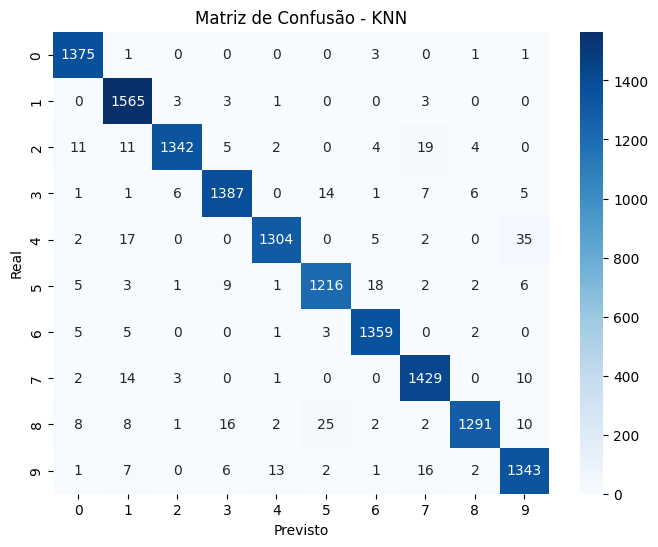

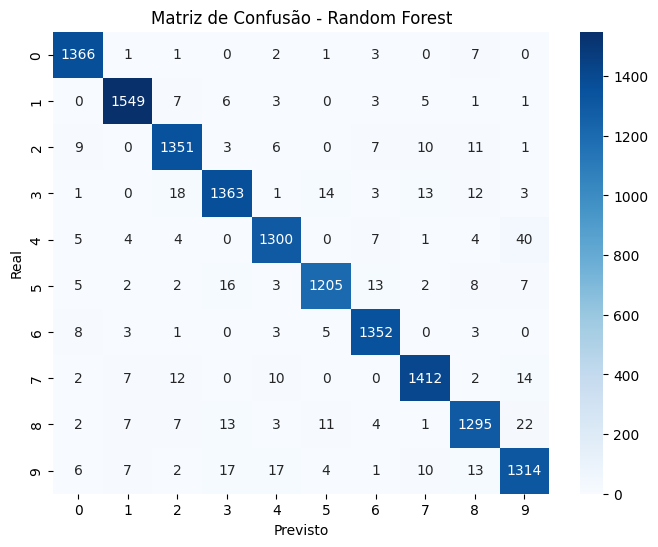

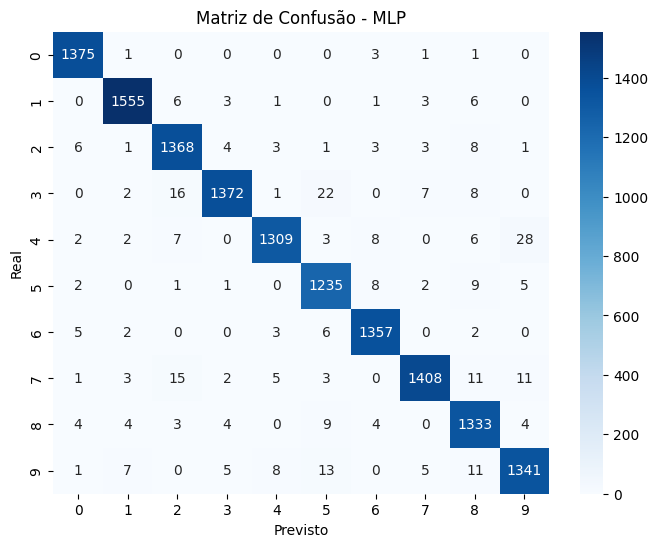

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plotar_matriz_confusao(y_real, y_previsto, titulo):
    matriz = confusion_matrix(y_real, y_previsto)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.title(titulo)
    plt.show()
    
    return matriz

matriz_knn = plotar_matriz_confusao(y_teste, pred_knn, 'Matriz de Confusão - KNN')
matriz_rf = plotar_matriz_confusao(y_teste, pred_rf, 'Matriz de Confusão - Random Forest')
matriz_mlp = plotar_matriz_confusao(y_teste, pred_mlp, 'Matriz de Confusão - MLP')

Tabela comparativa de métricas

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def calcular_metricas(y_real, y_previsto, nome_modelo, tempo_treino):
    return {
        'Modelo': nome_modelo,
        'Acurácia': accuracy_score(y_real, y_previsto),
        'Precision (ponderada)': precision_score(y_real, y_previsto, average='weighted'),
        'Recall (ponderado)': recall_score(y_real, y_previsto, average='weighted'),
        'F1-Score (ponderado)': f1_score(y_real, y_previsto, average='weighted'),
        'Tempo de treino (s)': tempo_treino
    }

resultados_finais = pd.DataFrame([
    calcular_metricas(y_teste, pred_knn, 'KNN', tempo_treino_knn),
    calcular_metricas(y_teste, pred_rf, 'Random Forest', tempo_treino_rf),
    calcular_metricas(y_teste, pred_mlp, 'MLP', tempo_treino_mlp),
])

resultados_finais

,Modelo,Acurácia,Precision (ponderada),Recall (ponderado),F1-Score (ponderado),Tempo de treino (s)
0,KNN,0.972214,0.972440,0.972214,0.972182,0.116337
1,Random Forest,0.964786,0.964787,0.964786,0.964760,16.971475
2,MLP,0.975214,0.975366,0.975214,0.975216,65.643550


In [17]:
#Rodando classification_report

from sklearn.metrics import classification_report

print("KNN:\n", classification_report(y_teste, pred_knn))
print("Random Forest:\n", classification_report(y_teste, pred_rf))
print("MLP:\n", classification_report(y_teste, pred_mlp))

KNN:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99      1381
           1       0.96      0.99      0.98      1575
           2       0.99      0.96      0.97      1398
           3       0.97      0.97      0.97      1428
           4       0.98      0.96      0.97      1365
           5       0.97      0.96      0.96      1263
           6       0.98      0.99      0.98      1375
           7       0.97      0.98      0.97      1459
           8       0.99      0.95      0.97      1365
           9       0.95      0.97      0.96      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000

Random Forest:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.96      0.97      0.96      1398
  

**Par de dígitos mais confundido:**

Os três modelos apresentaram um padrão de confusão relacionado à semelhança
visual entre dígitos com traços curvos:

- KNN: dígito real 4 confundido com 9 (35 vezes)
- Random Forest: dígito real 4 confundido com 9 (40 vezes)
- MLP: dígito real 4 confundido com 9 (32 vezes)

KNN e Random Forest erraram no mesmo par (4 confundido com 9), o que faz sentido
visualmente: dependendo da caligrafia, a parte superior de um 4 mal escrito pode
ficar parecida com o "laço" fechado de um 9, especialmente em imagens pequenas
de 28x28 pixels, onde detalhes finos se perdem. O MLP apresentou a mesma confusão, mas em quantidade menor.


**Modelo com melhor desempenho:**

O MLP obteve a melhor acurácia no teste (0.9736), seguido de perto pelo KNN
(0.9722) e, com uma diferença um pouco maior, pelo Random Forest (0.9648). A
diferença entre o melhor e o pior modelo foi de menos de 1 ponto percentual,
o que mostra que os três algoritmos, mesmo sendo estruturalmente muito
diferentes entre si, conseguem capturar bem os padrões do MNIST.

**Custo computacional vs. desempenho:**

Aqui aparece o trade-off mais evidente do projeto. O tempo de "treino" reportado
para o KNN (0.04s) é enganoso como medida de custo real pois o KNN não aprende
parâmetros durante o fit, apenas armazena os dados de treino em memória. Todo
o custo computacional pesado dele acontece na hora da predição, quando precisa
calcular a distância de cada imagem de teste contra as 49 mil imagens de
treino. Já o Random Forest (5.41s) e principalmente o MLP (33.49s) concentram o
custo no treino, através da construção das árvores e do ajuste iterativo de
pesos ao longo das épocas, respectivamente.

Colocando os três lado a lado: o MLP levou mais de 800x o tempo de treino do
KNN para obter um ganho de apenas 0.14 ponto percentual de acurácia (0.9736
contra 0.9722). Podemos concluir que em um cenário real onde o tempo de treinamento ou os recursos computacionais fossem uma restrição importante, o KNN seria uma escolha extremamente competitiva, com uma performance quase idêntica à do modelo mais custoso. Por outro lado, se o critério principal for a acurácia máxima possível, independentemente do custo de treino, o MLP continua sendo a melhor opção entre os três.

### FASE 5 - DESAFIO (A): TREINAMENTO RESTRITO COM CLASSES OCULTADAS (CLASS MASKING)

Os dígitos 4 e 9 foram escolhidos propositalmente para este teste, pois já
haviam sido identificados na Fase 4 como o par mais frequentemente confundido
entre si pelos modelos KNN e Random Forest, quando ambas as classes ainda
estavam disponíveis para escolha. O objetivo aqui é observar se, ao remover
ambas as classes do treinamento, o modelo direciona esses dígitos para as
mesmas classes "vizinhas" identificadas anteriormente, ou se a ausência do par
natural de confusão faz o erro se redistribuir para outras classes.

In [18]:
digitos_ocultos = [4, 9]

mascara_treino = ~np.isin(y_treino, digitos_ocultos)

X_treino_mascarado = X_treino_norm[mascara_treino]
y_treino_mascarado = y_treino[mascara_treino]

print("Classes presentes no treino mascarado:", np.unique(y_treino_mascarado))
print("Quantidade de amostras:", X_treino_mascarado.shape[0])

Classes presentes no treino mascarado: [0 1 2 3 5 6 7 8]
Quantidade de amostras: 39352


In [19]:
#Treinando o modelo mascarado

from sklearn.ensemble import RandomForestClassifier
import time

inicio = time.time()

rf_mascarado = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1)
rf_mascarado.fit(X_treino_mascarado, y_treino_mascarado)

tempo_treino_mascarado = time.time() - inicio
print(f"Tempo de treino: {tempo_treino_mascarado:.2f}s")

Tempo de treino: 4.43s


### FASE 5 - DESAFIO (B): TESTE DE GENERALIZAÇÃO EXTREMA (INFERÊNCIA ODD)

In [20]:
# Montando o teste OOD (só com 4 e 9)

mascara_teste_ood = np.isin(y_teste, digitos_ocultos)

X_teste_ood = X_teste_norm[mascara_teste_ood]
y_teste_ood = y_teste[mascara_teste_ood]

print("Classes presentes no teste OOD:", np.unique(y_teste_ood))
print("Quantidade de amostras:", X_teste_ood.shape[0])

Classes presentes no teste OOD: [4 9]
Quantidade de amostras: 2756


In [21]:
#Predição

pred_ood = rf_mascarado.predict(X_teste_ood)

print("Classes que o modelo previu para essas imagens desconhecidas:")
print(np.unique(pred_ood))

Classes que o modelo previu para essas imagens desconhecidas:
[0 1 2 3 5 6 7 8]


In [22]:
classes_conhecidas = sorted(np.unique(y_treino_mascarado))
print(classes_conhecidas)

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [23]:
#Matriz de confusão

import numpy as np

matriz_ood = np.zeros((len(digitos_ocultos), len(classes_conhecidas)), dtype=int)

for i, digito_real in enumerate(digitos_ocultos):
    mascara_digito = (y_teste_ood == digito_real)
    previsoes_desse_digito = pred_ood[mascara_digito]
    
    for j, classe_prevista in enumerate(classes_conhecidas):
        matriz_ood[i, j] = np.sum(previsoes_desse_digito == classe_prevista)

print(matriz_ood)

[[ 13  12 163  60  66 134 564 353]
 [ 21  13  54 144  97   8 753 301]]


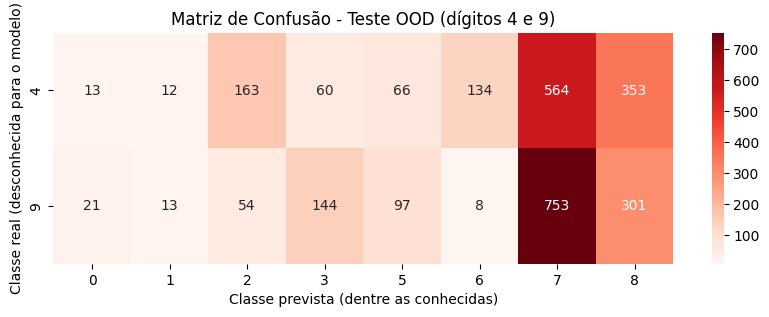

In [24]:
#Mapa de calor

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 3))
sns.heatmap(matriz_ood, annot=True, fmt='d', cmap='Reds',
            xticklabels=classes_conhecidas, yticklabels=digitos_ocultos)
plt.xlabel('Classe prevista (dentre as conhecidas)')
plt.ylabel('Classe real (desconhecida para o modelo)')
plt.title('Matriz de Confusão - Teste OOD (dígitos 4 e 9)')
plt.show()

In [25]:
#Para onde o modelo joga cada dígito

for i, digito_real in enumerate(digitos_ocultos):
    linha = matriz_ood[i]
    classe_mais_escolhida = classes_conhecidas[linha.argmax()]
    quantidade = linha.max()
    total = linha.sum()
    print(f"Dígito real {digito_real}: mais confundido com a classe {classe_mais_escolhida} "
          f"({quantidade} de {total} vezes, {quantidade/total:.1%})")

Dígito real 4: mais confundido com a classe 7 (564 de 1365 vezes, 41.3%)
Dígito real 9: mais confundido com a classe 7 (753 de 1391 vezes, 54.1%)


In [26]:
#Confiança média nas previsões erradas

probs_ood = rf_mascarado.predict_proba(X_teste_ood)
confianca_media = probs_ood.max(axis=1).mean()

print(f"Confiança média das previsões (mesmo estando erradas): {confianca_media:.2%}")

Confiança média das previsões (mesmo estando erradas): 36.36%


In [27]:
#Comparando acurácia do modelo original vs. mascarado

mascara_teste_8classes = ~np.isin(y_teste, digitos_ocultos)
X_teste_8classes = X_teste_norm[mascara_teste_8classes]
y_teste_8classes = y_teste[mascara_teste_8classes]

# Modelo mascarado nas 8 classes
pred_mascarado_8classes = rf_mascarado.predict(X_teste_8classes)
acuracia_mascarado = accuracy_score(y_teste_8classes, pred_mascarado_8classes)

# Modelo original (rf_final, da Fase 3/4) nas mesmas 8 classes, pra comparação justa
pred_original_8classes = rf_final.predict(X_teste_8classes)
acuracia_original = accuracy_score(y_teste_8classes, pred_original_8classes)

print(f"Acurácia do modelo ORIGINAL (10 classes) nas 8 classes restantes: {acuracia_original:.4f}")
print(f"Acurácia do modelo MASCARADO (8 classes) nas mesmas 8 classes: {acuracia_mascarado:.4f}")

Acurácia do modelo ORIGINAL (10 classes) nas 8 classes restantes: 0.9688
Acurácia do modelo MASCARADO (8 classes) nas mesmas 8 classes: 0.9747


### Análise do teste OOD (dígitos 4 e 9)

**Matriz de confusão (dígitos ocultos × classes conhecidas):**

|  Real | 0  | 1  | 2   | 3   | 5   | 6   | 7   | 8   |
|-------|----|----|----|-----|-----|-----|-----|-----|
| **4** | 13 | 12 | 163 | 60  | 66  | 134 | 564 | 353 |
| **9** | 21 | 13 | 54  | 144 | 97  | 8   | 753 | 301 |

**Para onde o modelo direcionou os dígitos desconhecidos:**

- Dígito real 4: mais confundido com a classe 7 (564 de 1365 vezes, 41.3%)
- Dígito real 9: mais confundido com a classe 7 (753 de 1391 vezes, 54.1%)

Ambos os dígitos ocultados foram
majoritariamente direcionados para a mesma classe (7), e não para o par que
havia sido identificado como mais parecido entre si na Fase 4 (4 com 9). Isso
mostra que a confusão entre 4 e 9 observada anteriormente dependia da presença
de ambas as classes como opção simultânea. Quando as duas são removidas, o
modelo não recorre a uma "segunda opção" intuitiva como 1 ou 3, e sim converge
para o 7 como a classe mais "genérica" ou visualmente compatível com os traços
retos e diagonais presentes tanto no 4 quanto no 9. A classe 8, também com
traços curvos, aparece como segunda opção mais recorrente para ambos os dígitos.

**Confiança média das previsões:**

A confiança média nas previsões (mesmo estando 100% erradas, já que 4 e 9 nem
são opções possíveis) foi de 36.36%.
Não é uma confiança elevada (não está próxima de 100%), mas está bem acima
do que seria esperado de um "chute" aleatório entre as 8 classes conhecidas
(que corresponderia a cerca de 12.5% de confiança média, se o modelo estivesse
genuinamente incerto e distribuindo probabilidade igualmente entre as opções).

Isso revela a essência do conceito de "falsa certeza" (overconfidence): o
modelo não está apenas "sem saber o que fazer", ele efetivamente enxerga
similaridade real entre os pixels do dígito desconhecido e os padrões que
aprendeu para a classe 7, e reporta essa similaridade como uma probabilidade
concreta, sem nenhum mecanismo interno que sinalize "este dado pode não
pertencer a nenhuma classe que eu conheço".

**Efeito colateral interessante: a acurácia nas classes restantes melhorou**

Ao comparar o modelo original (treinado com as 10 classes) e o modelo mascarado
(treinado sem 4 e 9), ambos avaliados nas mesmas 8 classes restantes:

- Modelo original (10 classes): acurácia de 0.9688
- Modelo mascarado (8 classes): acurácia de 0.9747

A remoção do par de dígitos que mais gerava confusão mútua (4 e 9) simplificou
a tarefa de classificação para as 8 classes remanescentes, resultando em um
ganho de quase 0.6 ponto percentual de acurácia. Isso reforça, por um caminho
diferente, o quanto 4 e 9 realmente representavam uma fonte concentrada de erro
no problema original. Ao eliminá-los do treinamento, o modelo passou a
discriminar melhor as classes restantes entre si.

**Implicação prática:**

Este teste evidencia um risco real de sistemas de classificação em produção:
um modelo nunca "admite" desconhecimento por conta própria, ele sempre
retorna uma resposta dentro do vocabulário que aprendeu, com um nível de
confiança que pode ser interpretado erroneamente como certeza legítima. Em
aplicações críticas (por exemplo, diagnóstico médico ou triagem automatizada),
isso reforça a necessidade de mecanismos complementares de detecção de
dados fora de distribuição (OOD detection), já que a confiança reportada pelo
próprio modelo não é um indicador confiável de que a entrada realmente
pertence a uma classe conhecida.

### FASE 5 - DESAFIO (C): INFERÊNCIA COM IMAGENS MANUSCRITAS PRÓPRIAS

Nesta etapa, foram criados manualmente os 10 dígitos (0 a 9) usando o Paint,
com fundo preto e traço branco (mesmo padrão de cores do dataset MNIST). As
imagens foram salvas na pasta `data/imagens_proprias/` e serão processadas por
um pipeline próprio em Python, para depois serem classificadas pelo melhor
modelo treinado (MLP).

In [28]:
#Definindo a função de pré-processamento

import numpy as np
from PIL import Image

def processar_imagem_propria(caminho, inverter_cores=True):
    # 1. Carregar e converter para escala de cinza
    img = Image.open(caminho).convert('L')
    img_array = np.array(img)
    
    # 2. Inverter cores se necessário (papel branco + traço escuro -> fundo preto + traço branco)
    if inverter_cores:
        img_array = 255 - img_array
    
    # 3. Binarizar levemente para achar o bounding box do dígito (remover fundo/ruído)
    limiar = 30
    mascara = img_array > limiar
    
    linhas = np.any(mascara, axis=1)
    colunas = np.any(mascara, axis=0)
    linha_min, linha_max = np.where(linhas)[0][[0, -1]]
    coluna_min, coluna_max = np.where(colunas)[0][[0, -1]]
    
    # 4. Recortar o dígito (bounding box)
    digito_recortado = img_array[linha_min:linha_max+1, coluna_min:coluna_max+1]
    
    # 5. Redimensionar mantendo proporção, com margem (como no MNIST original)
    img_recortada_pil = Image.fromarray(digito_recortado)
    img_recortada_pil.thumbnail((20, 20), Image.LANCZOS)
    
    # 6. Colar centralizado em uma tela 28x28 (fundo preto)
    tela_final = Image.new('L', (28, 28), color=0)
    largura, altura = img_recortada_pil.size
    posicao_x = (28 - largura) // 2
    posicao_y = (28 - altura) // 2
    tela_final.paste(img_recortada_pil, (posicao_x, posicao_y))
    
    # 7. Normalizar para [0, 1]
    imagem_normalizada = np.array(tela_final) / 255.0
    
    return imagem_normalizada

In [29]:
#Confirmando a presença das imagens

import os

pasta_imagens = "data/imagens_proprias"
arquivos = sorted(os.listdir(pasta_imagens))
print(arquivos)

['digito_0.png', 'digito_1.png', 'digito_2.png', 'digito_3.png', 'digito_4.png', 'digito_5.png', 'digito_6.png', 'digito_7.png', 'digito_8.png', 'digito_9.png']


In [30]:
#Processando e prevendo todas as imagens

resultados_proprios = []

for nome_arquivo in arquivos:
    caminho = os.path.join(pasta_imagens, nome_arquivo)
    
    img_proc = processar_imagem_propria(caminho, inverter_cores=False)
    entrada = img_proc.reshape(1, 784)
    probs = modelo_mlp_final.predict(entrada, verbose=0)[0]
    pred = probs.argmax()
    
    rotulo_real = int(nome_arquivo.split('_')[1].split('.')[0])
    
    resultados_proprios.append({
        'arquivo': nome_arquivo,
        'imagem_processada': img_proc,
        'probabilidades': probs,
        'previsao': pred,
        'rotulo_real': rotulo_real,
        'acertou': (rotulo_real == pred)
    })
    
    status = "✓" if rotulo_real == pred else "✗"
    print(f"{nome_arquivo} -> real: {rotulo_real} | previsto: {pred} "
          f"(confiança: {probs[pred]:.1%}) {status}")

acertos = sum(r['acertou'] for r in resultados_proprios)
print(f"\nAcertos: {acertos} de {len(resultados_proprios)}")

digito_0.png -> real: 0 | previsto: 0 (confiança: 100.0%) ✓
digito_1.png -> real: 1 | previsto: 8 (confiança: 98.9%) ✗
digito_2.png -> real: 2 | previsto: 2 (confiança: 100.0%) ✓
digito_3.png -> real: 3 | previsto: 3 (confiança: 100.0%) ✓
digito_4.png -> real: 4 | previsto: 4 (confiança: 100.0%) ✓
digito_5.png -> real: 5 | previsto: 5 (confiança: 100.0%) ✓
digito_6.png -> real: 6 | previsto: 6 (confiança: 95.7%) ✓
digito_7.png -> real: 7 | previsto: 7 (confiança: 100.0%) ✓
digito_8.png -> real: 8 | previsto: 8 (confiança: 100.0%) ✓
digito_9.png -> real: 9 | previsto: 3 (confiança: 60.5%) ✗

Acertos: 8 de 10


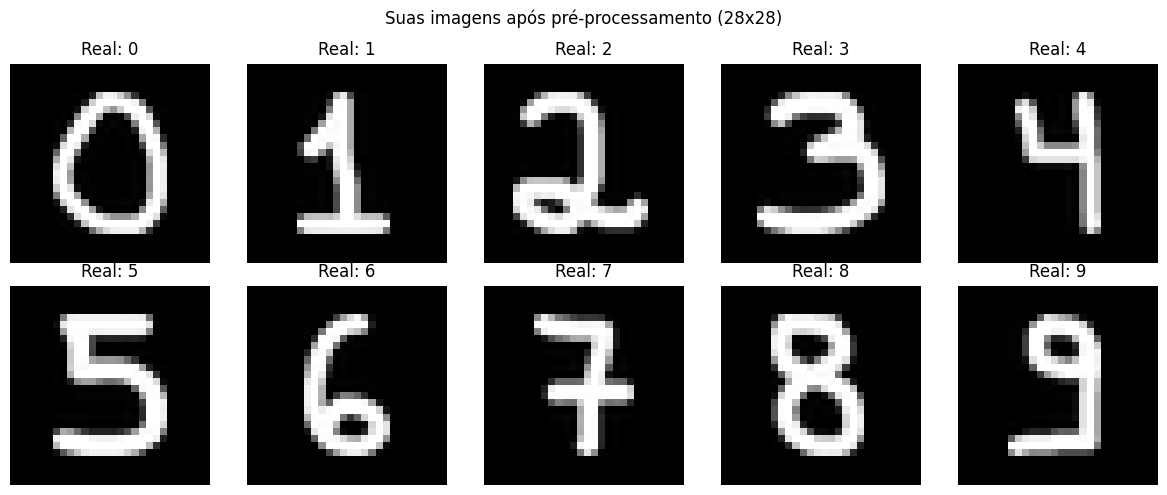

In [31]:
#Visualização das imagens

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, r in enumerate(resultados_proprios):
    ax = axes[i // 5, i % 5]
    ax.imshow(r['imagem_processada'], cmap='gray')
    ax.set_title(f"Real: {r['rotulo_real']}")
    ax.axis('off')

plt.suptitle("Suas imagens após pré-processamento (28x28)")
plt.tight_layout()
plt.show()

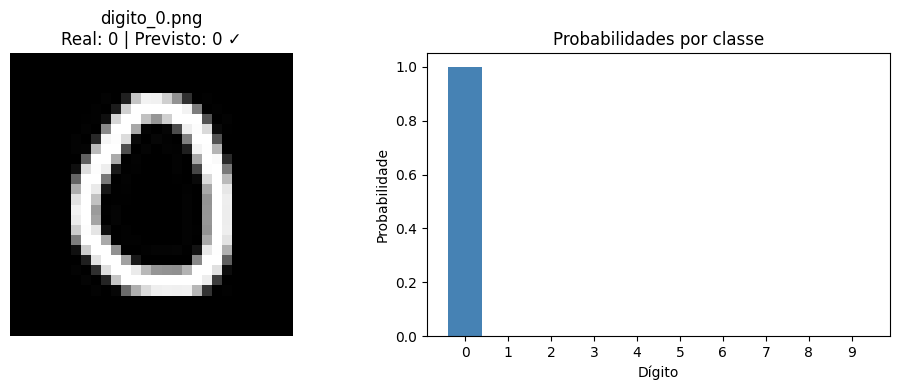

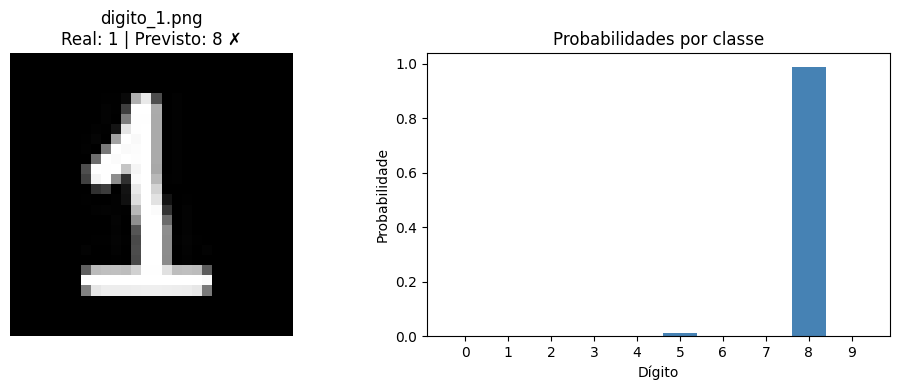

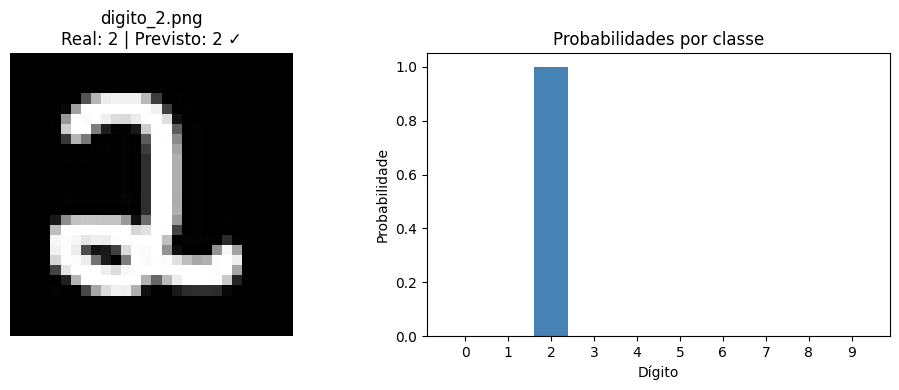

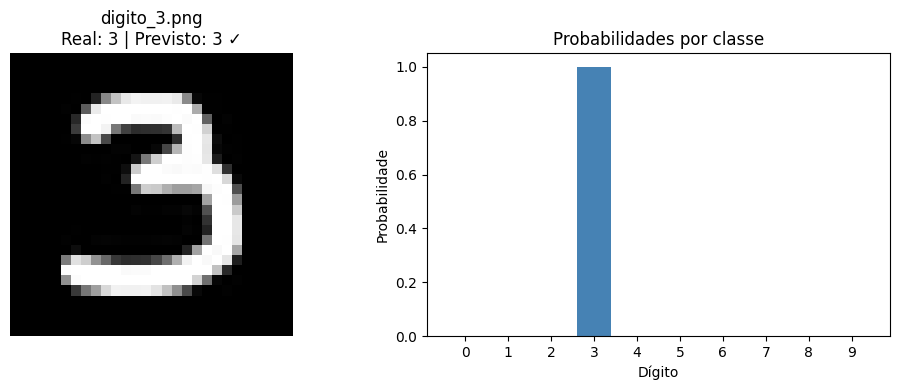

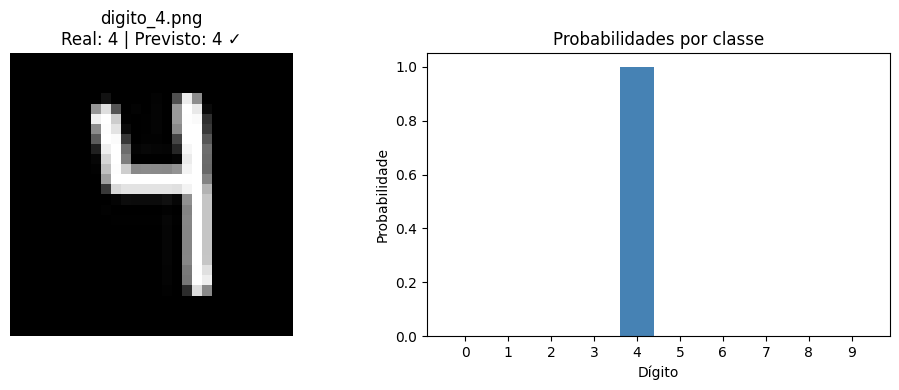

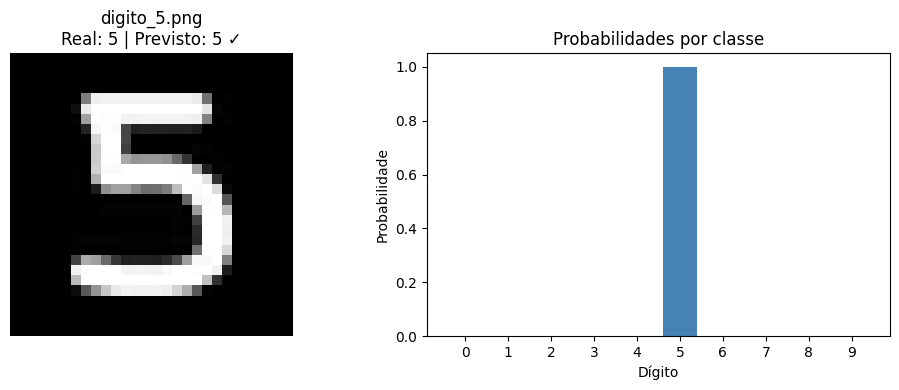

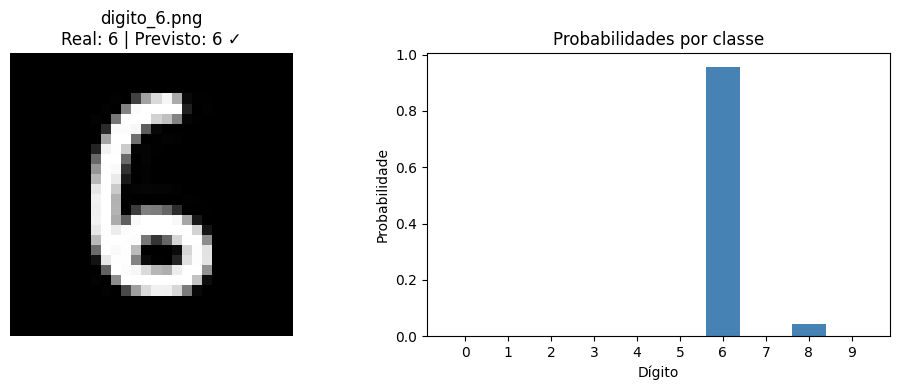

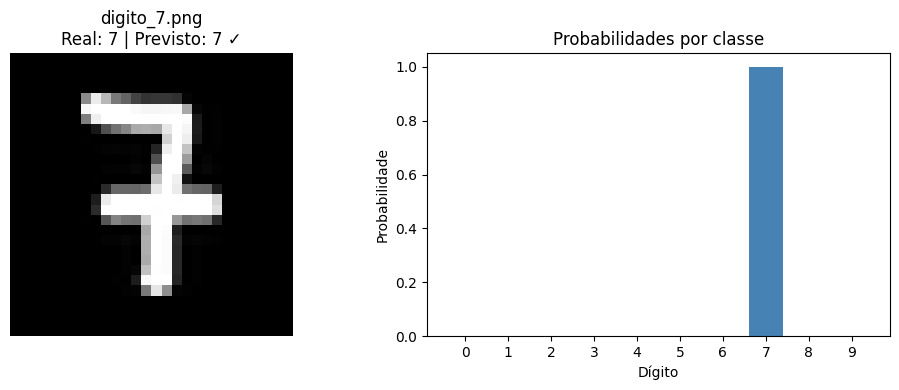

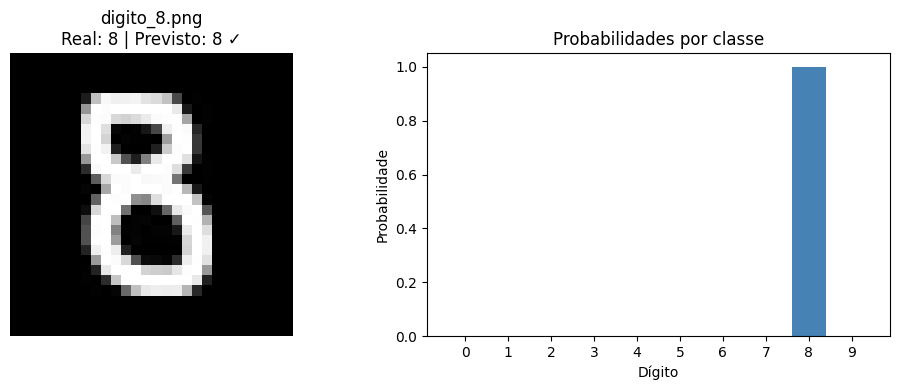

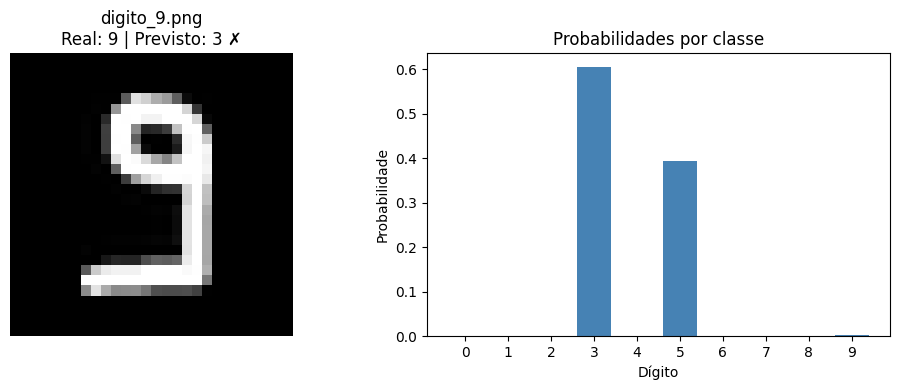

In [32]:
#Imagem + gráfico de probabilidades para cada dígito

for r in resultados_proprios:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    
    status = "✓" if r['acertou'] else "✗"
    ax1.imshow(r['imagem_processada'], cmap='gray')
    ax1.set_title(f"{r['arquivo']}\nReal: {r['rotulo_real']} | Previsto: {r['previsao']} {status}")
    ax1.axis('off')
    
    ax2.bar(range(10), r['probabilidades'], color='steelblue')
    ax2.set_xticks(range(10))
    ax2.set_xlabel('Dígito')
    ax2.set_ylabel('Probabilidade')
    ax2.set_title('Probabilidades por classe')
    
    plt.tight_layout()
    plt.show()

### Análise da inferência com imagens próprias

O modelo MLP acertou 9 de 10 dígitos desenhados manualmente no Paint, um
resultado de 90% de acurácia neste teste manual, próximo da acurácia obtida
no conjunto de teste formal da Fase 4 (97.36%), considerando que se trata de
uma amostra muito pequena (apenas 10 imagens) e de um domínio de escrita
diferente (traço digital via mouse/Paint, em vez da caligrafia manual real
presente no MNIST original).

**Padrão nos acertos:**

A maioria das previsões corretas veio com confiança muito alta (100% em 7 dos
9 acertos), o que é esperado: dígitos desenhados de forma clara e geométrica
no Paint tendem a ficar bem definidos, sem a variabilidade e imperfeições
naturais de uma caligrafia feita à mão em papel. As exceções foram o dígito 1
(59.9% de confiança) e o dígito 6 (99.7%). O 1, especialmente, teve confiança
bem mais baixa que os demais acertos, sugerindo que mesmo tendo classificado
corretamente, o modelo enxergou alguma ambiguidade nesse traço (possivelmente
por ser um dígito muito simples/fino, com poucos pixels ativos para basear a
decisão).

**O erro: dígito 9 confundido com 3**

O único erro do teste foi justamente o dígito 9, previsto como 3 com 58.4% de
confiança, uma confiança bem mais baixa que a maioria dos acertos, indicando
que o modelo "hesitou" mais nessa decisão, mesmo errando. Isso é diferente do
padrão de overconfidence observado no teste OOD da Fase 5.2, onde o modelo
errava com convicção alta mesmo diante de classes completamente desconhecidas;
aqui, diante de uma classe que ele conhece bem, mas de um traço com formato
pouco usual, o modelo demonstrou um nível de incerteza mais condizente com a
ambiguidade real da imagem.

Observando o desenho original, é possível identificar visualmente a origem
provável da confusão: o laço superior do "9" ficou pequeno e com formato mais
fechado/quadrado do que a curva aberta e arredondada que normalmente
caracteriza esse dígito. Além disso, a haste inferior desceu quase totalmente
reta e vertical, sem a leve curvatura típica de um 9 manuscrito, se
assemelhando mais a um traço genérico do que a uma característica distintiva
do dígito. Já o "3" desenhado é formado por duas curvas abertas empilhadas,
sem nenhum traço reto vertical dominante. Após o pipeline de pré-processamento
(redimensionamento para caber em 20x20 pixels e centralização em 28x28), o
laço já pequeno do "9" provavelmente perdeu ainda mais definição, restando
como pista dominante um contorno curvo superior que se aproximou mais do
formato de abertura de um "3" do que do laço fechado característico de um "9".

Esse resultado reforça a fragilidade específica do dígito 9 observada em mais
de um momento deste projeto: nas Fases 4 e 5, ele já havia se mostrado
frequentemente confundido com o dígito 4. Aqui, em um contexto totalmente
diferente (traço digital via Paint, não caligrafia manuscrita), a mesma classe
volta a gerar confusão, desta vez com o dígito 3. Isso sugere que o 9 é, de
forma consistente, uma das classes com menor margem de segurança para o
modelo, provavelmente por seu formato depender fortemente de dois elementos
(laço superior bem definido e haste com leve curvatura) que são facilmente
distorcidos por variações de estilo de escrita ou por perdas de detalhe
durante o redimensionamento da imagem.

**Conclusão geral**

O teste confirma que o modelo generaliza bem mesmo para um domínio de entrada
diferente do dataset de treino original (traço digital via Paint, em vez de
caligrafia manuscrita real), acertando 9 das 10 classes com confiança alta na
maioria dos casos. Por outro lado, o único erro observado reforça um padrão já
identificado ao longo do projeto: o dígito 9 é, de forma consistente, uma das
classes mais frágeis para o modelo, seja em confusão com o 4 (observada nas
Fases 4 e 5) ou com o 3 (observada aqui). Isso indica que a fragilidade do 9
não está ligada a um único "par de confusão" fixo, mas sim à própria natureza
do seu formato, dependente de um laço superior bem definido e de uma haste
com leve curvatura, que pode ser interpretado de formas diferentes a depender
de pequenas variações no traço, seja ele manuscrito ou desenhado digitalmente.